In [100]:
import tifffile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import pathlib
from scipy.ndimage import distance_transform_edt

import skimage
from skimage.feature import peak_local_max
from skimage import util,  restoration
from skimage.filters import threshold_otsu, threshold_isodata, threshold_li, threshold_minimum, threshold_mean, threshold_yen, threshold_multiotsu, threshold_triangle
from skimage.segmentation import clear_border, expand_labels, watershed
from skimage.measure import label, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, closing,  disk, dilation
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi
from skimage.filters import try_all_threshold
from skimage.filters import gaussian, median as median_filter, threshold_li, threshold_mean, threshold_triangle, threshold_yen, threshold_local
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import closing, disk, square, erosion, remove_small_holes
from skimage.segmentation import watershed, expand_labels
from skimage.feature import peak_local_max
import warnings
warnings.filterwarnings("ignore")
import pathlib
from skimage.morphology import closing,  disk, dilation, erosion, ball
from skimage.measure import regionprops
from skimage.exposure import rescale_intensity
import contextlib
import joblib
from tqdm import tqdm
from joblib import Parallel, delayed
import matplotlib.gridspec as gridspec
import skimage.measure as skm

GRID = 8  # 8x8 grid (blanks allowed)


In [109]:
def segment_circles(crop, min_dist = 4):
    """Threshold + watershed circles within a device crop."""
    rescaled = rescale_intensity(crop.astype(float), out_range=(0, 255))
    circles = rescaled > threshold_li(rescaled)

    labelled = label(circles)
    coords = peak_local_max(rescaled, min_distance=min_dist)
    markers = np.zeros(rescaled.shape, dtype=np.uint32)
    markers[tuple(np.round(coords).astype(int).T)] = np.arange(len(coords)) + 1
    seg = expand_labels(watershed(-rescaled, markers, mask=labelled > 0), distance=1)
    return seg, rescaled


def fit_uniform_grid(values, k, s_min, s_max, n_s=200, n_iter=20):
    """Fit k evenly-spaced grid positions o, o+s, ..., o+(k-1)s to 1-D `values`.

    Blanks are fine: each value snaps to its nearest grid index in 0..k-1 and we
    minimise the total squared residual over (s, o). Grid-search s, then refine
    (s, o) by least squares given current index assignments.
    """
    values = np.asarray(values, dtype=float)
    best = (np.inf, None, None)
    for s in np.linspace(s_min, s_max, n_s):
        o = float(values.min())
        for _ in range(n_iter):
            idx = np.clip(np.round((values - o) / s).astype(int), 0, k - 1)
            A = np.column_stack([np.ones_like(idx, dtype=float), idx.astype(float)])
            (o_new, s_new), *_ = np.linalg.lstsq(A, values, rcond=None)
            if abs(o_new - o) < 1e-6 and abs(s_new - s) < 1e-6:
                o, s = o_new, s_new
                break
            o, s = o_new, s_new
        idx = np.clip(np.round((values - o) / s).astype(int), 0, k - 1)
        resid = float(np.sum((values - (o + idx * s)) ** 2))
        if resid < best[0]:
            best = (resid, s, o)
    _, s, o = best
    return o + np.arange(k) * s, s, o


def _rotate(ys, xs, t, cy0, cx0):
    """Rotate (ys, xs) by angle t (radians) about (cy0, cx0)."""
    cos_t, sin_t = np.cos(t), np.sin(t)
    yr = cy0 + cos_t * (ys - cy0) + sin_t * (xs - cx0)
    xr = cx0 - sin_t * (ys - cy0) + cos_t * (xs - cx0)
    return yr, xr


def fit_rotated_uniform_grid(ys, xs, H, W, k=8,
                             theta_range_deg=(-30, 30), n_theta=61,
                             s_frac_range=(0.07, 0.18)):
    """Fit a rotated k×k uniform grid to spot centroids in a crop of shape (H, W).

    Searches rotation angle theta, then for each theta fits independent
    1-D uniform grids along the rotated y' and x' axes. Returns the angle
    + 1-D grid parameters (in rotated pixel coords) + the rotation centre.
    """
    ys = np.asarray(ys, dtype=float)
    xs = np.asarray(xs, dtype=float)
    cy0, cx0 = H / 2.0, W / 2.0
    extent = max(H, W)
    s_min, s_max = s_frac_range[0] * extent, s_frac_range[1] * extent

    best = (np.inf, 0.0, None, None, None, None)
    for theta_deg in np.linspace(theta_range_deg[0], theta_range_deg[1], n_theta):
        t = np.radians(theta_deg)
        yr, xr = _rotate(ys, xs, t, cy0, cx0)
        _, sy, oy = fit_uniform_grid(yr, k, s_min, s_max, n_s=60)
        _, sx, ox = fit_uniform_grid(xr, k, s_min, s_max, n_s=60)
        iy = np.clip(np.round((yr - oy) / sy).astype(int), 0, k - 1)
        ix = np.clip(np.round((xr - ox) / sx).astype(int), 0, k - 1)
        resid = float(np.sum((yr - (oy + iy * sy)) ** 2 +
                             (xr - (ox + ix * sx)) ** 2))
        if resid < best[0]:
            best = (resid, t, sy, oy, sx, ox)
    _, t, sy, oy, sx, ox = best
    return {"theta": t, "sy": sy, "oy": oy, "sx": sx, "ox": ox,
            "cy0": cy0, "cx0": cx0,
            "row_centres_rot": oy + np.arange(k) * sy,
            "col_centres_rot": ox + np.arange(k) * sx}


In [110]:
def sort_props_book_order(props, row_tol_frac=0.5):
    """Sort regionprops left-to-right, top-to-bottom (reading order).

    Clusters centroids into rows using a tolerance derived from the
    median equivalent diameter, so small vertical jitter inside a row
    does not scramble the order.
    """
    if not props:
        return []
    diameters = [p.equivalent_diameter for p in props]
    tol = max(1.0, np.median(diameters) * row_tol_frac)

    by_y = sorted(props, key=lambda p: p.centroid[0])
    rows, current = [], [by_y[0]]
    for p in by_y[1:]:
        if p.centroid[0] - current[-1].centroid[0] <= tol:
            current.append(p)
        else:
            rows.append(current)
            current = [p]
    rows.append(current)

    ordered = []
    for row in rows:
        ordered.extend(sorted(row, key=lambda p: p.centroid[1]))
    return ordered

In [111]:
def identify_devices_and_quantify(folder, image_name):
    test_image = tifffile.imread(os.path.join(folder, f"{image_name}.Tif"))

    device_mask = test_image > threshold_triangle(test_image)

    # Distance-transform watershed: split any merged/touching devices.
    # We expect 4 roughly square devices, so seed the watershed with up to
    # ~4 well-separated local maxima of the distance transform.
    dist = distance_transform_edt(device_mask)
    # min_distance is large (~half a device width) so we don't oversplit a single square
    min_sep = int(max(20, 0.4 * np.sqrt(device_mask.sum() / 4)))
    peak_coords = peak_local_max(dist, min_distance=min_sep, labels=label(device_mask))
    seed_markers = np.zeros(device_mask.shape, dtype=np.int32)
    seed_markers[tuple(peak_coords.T)] = np.arange(1, len(peak_coords) + 1)
    labelled_devices_raw = watershed(-dist, seed_markers, mask=device_mask)

    fig, ax = plt.subplots()
    ax.imshow(labelled_devices_raw)
    ax.set_title(f"watershed-split devices ({labelled_devices_raw.max()} found)")

    # Keep only the 4 largest regions, reindex 1-4 L->R, T->B (reading order)
    props_all = skm.regionprops(labelled_devices_raw)
    top4 = sorted(props_all, key=lambda p: p.area, reverse=True)[:4]
    top4_sorted = sort_props_book_order(top4)

    label_map = np.zeros(labelled_devices_raw.max() + 1, dtype=labelled_devices_raw.dtype)
    for new_label, prop in enumerate(top4_sorted, start=1):
        label_map[prop.label] = new_label
    labelled_devices = label_map[labelled_devices_raw]


    device_ids = [d for d in sorted(np.unique(labelled_devices)) if d != 0]
    n = len(device_ids)

    # --- Pass 1: segment each device and fit its OWN rotated 8x8 grid ---
    device_results = {}
    for dev_id in device_ids:
        minr, minc, maxr, maxc = skm.regionprops((labelled_devices == dev_id).astype(int))[0].bbox
        crop = test_image[minr:maxr, minc:maxc]
        seg, rescaled = segment_circles(crop, min_dist=8)
        H, W = seg.shape

        centroids = {p.label: (p.centroid[0], p.centroid[1]) for p in skm.regionprops(seg)}
        ys = np.array([v[0] for v in centroids.values()])
        xs = np.array([v[1] for v in centroids.values()])

        fit = fit_rotated_uniform_grid(ys, xs, H, W, k=GRID)
        t, sy, oy, sx, ox = fit["theta"], fit["sy"], fit["oy"], fit["sx"], fit["ox"]
        cy0, cx0 = fit["cy0"], fit["cx0"]
        print(f"device {dev_id}: angle={np.degrees(t):+.2f}deg | "
              f"row spacing={sy:.1f} offset={oy:.1f} | col spacing={sx:.1f} offset={ox:.1f}")

        # Remap each circle to its (row, col) cell using rotated coords
        local_lmap = np.zeros(seg.max() + 1, dtype=np.int32)
        used = {}  # cell_id -> (local_id, distance)
        for local_id, (cy, cx) in centroids.items():
            yr, xr = _rotate(np.array([cy]), np.array([cx]), t, cy0, cx0)
            yr, xr = float(yr[0]), float(xr[0])
            r = int(np.clip(round((yr - oy) / sy), 0, GRID - 1))
            c = int(np.clip(round((xr - ox) / sx), 0, GRID - 1))
            cell_id = r * GRID + c + 1  # 1..64, position A1 == 1
            dist = np.hypot((oy + r * sy) - yr, (ox + c * sx) - xr)
            if cell_id in used and used[cell_id][1] <= dist:
                continue
            if cell_id in used:
                local_lmap[used[cell_id][0]] = 0
            used[cell_id] = (local_id, dist)
            local_lmap[local_id] = cell_id
        # Unmatched circles get fresh IDs above 64
        next_id = GRID * GRID + 1
        for local_id in centroids:
            if local_lmap[local_id] == 0:
                local_lmap[local_id] = next_id
                next_id += 1

        device_results[dev_id] = {
            "crop": crop, "rescaled": rescaled, "seg": local_lmap[seg],
            "fit": fit,
        }

    # --- Plot: 3-row figure ---
    fig = plt.figure(figsize=(5 * n, 15))
    gs = gridspec.GridSpec(3, n, figure=fig, height_ratios=[1, 1, 1])

    ax_raw = fig.add_subplot(gs[0, : n // 2])
    ax_raw.imshow(test_image)
    ax_raw.set_title("raw image")
    ax_raw.axis("off")

    ax_dev = fig.add_subplot(gs[0, n // 2 :])
    ax_dev.imshow(labelled_devices, cmap="bwr")
    for prop in skm.regionprops(labelled_devices):
        cy, cx = prop.centroid
        ax_dev.text(cx, cy, str(prop.label), color="black", fontsize=12,
                    ha="center", va="center", fontweight="bold")
    ax_dev.set_title(f"{n} devices, {GRID}x{GRID} grid IDs")
    ax_dev.axis("off")

    records = []
    for i, dev_id in enumerate(device_ids):
        res = device_results[dev_id]
        seg = res["seg"]
        H, W = seg.shape

        ax_overlay = fig.add_subplot(gs[1, i])
        ax_overlay.imshow(res["rescaled"], cmap="gray")
        ax_overlay.imshow(np.ma.masked_where(seg == 0, seg), cmap="bwr", alpha=0.3)
        # Draw rotated grid lines: forward-rotate endpoints from rotated frame back to image frame
        fit = res["fit"]
        t, cy0, cx0 = fit["theta"], fit["cy0"], fit["cx0"]
        cos_t, sin_t = np.cos(t), np.sin(t)

        def _back(yr, xr):
            y = cy0 + cos_t * (yr - cy0) - sin_t * (xr - cx0)
            x = cx0 + sin_t * (yr - cy0) + cos_t * (xr - cx0)
            return y, x

        # Extend each grid line across the device (a bit beyond the outer columns/rows)
        pad = max(fit["sx"], fit["sy"])
        xr_lo, xr_hi = fit["col_centres_rot"].min() - pad, fit["col_centres_rot"].max() + pad
        yr_lo, yr_hi = fit["row_centres_rot"].min() - pad, fit["row_centres_rot"].max() + pad
        for yr in fit["row_centres_rot"]:
            ys_l, xs_l = _back(np.array([yr, yr]), np.array([xr_lo, xr_hi]))
            ax_overlay.plot(xs_l, ys_l, color="lime", lw=0.4, alpha=0.7)
        for xr in fit["col_centres_rot"]:
            ys_l, xs_l = _back(np.array([yr_lo, yr_hi]), np.array([xr, xr]))
            ax_overlay.plot(xs_l, ys_l, color="lime", lw=0.4, alpha=0.7)
        ax_overlay.set_xlim(0, W); ax_overlay.set_ylim(H, 0)
        ax_overlay.set_title(f"device {dev_id} ({np.degrees(t):+.1f}°)")
        ax_overlay.axis("off")

        ax_lbl = fig.add_subplot(gs[2, i])
        ax_lbl.imshow(seg, cmap="bwr")
        for p in skm.regionprops(seg):
            cy, cx = p.centroid
            ax_lbl.text(cx, cy, str(p.label), color="black", fontsize=9,
                        ha="center", va="center", fontweight="bold")
        ax_lbl.set_title(f"device {dev_id} labels")
        ax_lbl.axis("off")

        pt = regionprops_table(seg, intensity_image=res["crop"],
                            properties=["label", "area", "mean_intensity"])
        df = pd.DataFrame(pt)
        df["device_id"] = dev_id
        df["circle_id"] = df["label"]
        df["total_intensity"] = (df["mean_intensity"] * df["area"]).astype(int)
        records.append(df[["device_id", "circle_id", "total_intensity"]])

    df_circles = (pd.concat(records, ignore_index=True)
                .sort_values(["device_id", "circle_id"])
                .reset_index(drop=True))
    plt.tight_layout()
    plt.savefig(os.path.join(folder, f"{image_name}_analysis.png"), dpi=300)
    plt.show()
    df_circles.to_csv(os.path.join(folder, f"{image_name}_circle_quantification.csv"), index=False)

device 1: angle=+2.00deg | row spacing=11.9 offset=39.7 | col spacing=12.0 offset=27.7
device 2: angle=+0.00deg | row spacing=12.2 offset=41.7 | col spacing=11.8 offset=31.6
device 3: angle=+3.00deg | row spacing=11.7 offset=45.3 | col spacing=11.9 offset=29.7
device 4: angle=+3.00deg | row spacing=11.7 offset=40.5 | col spacing=12.1 offset=29.8


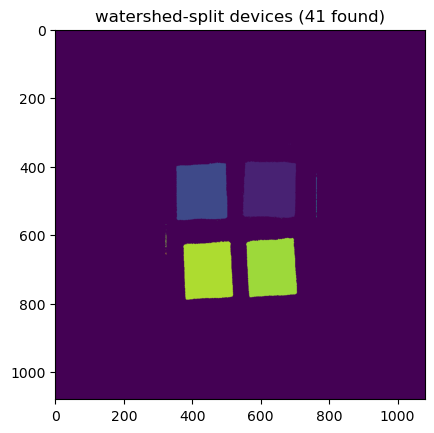

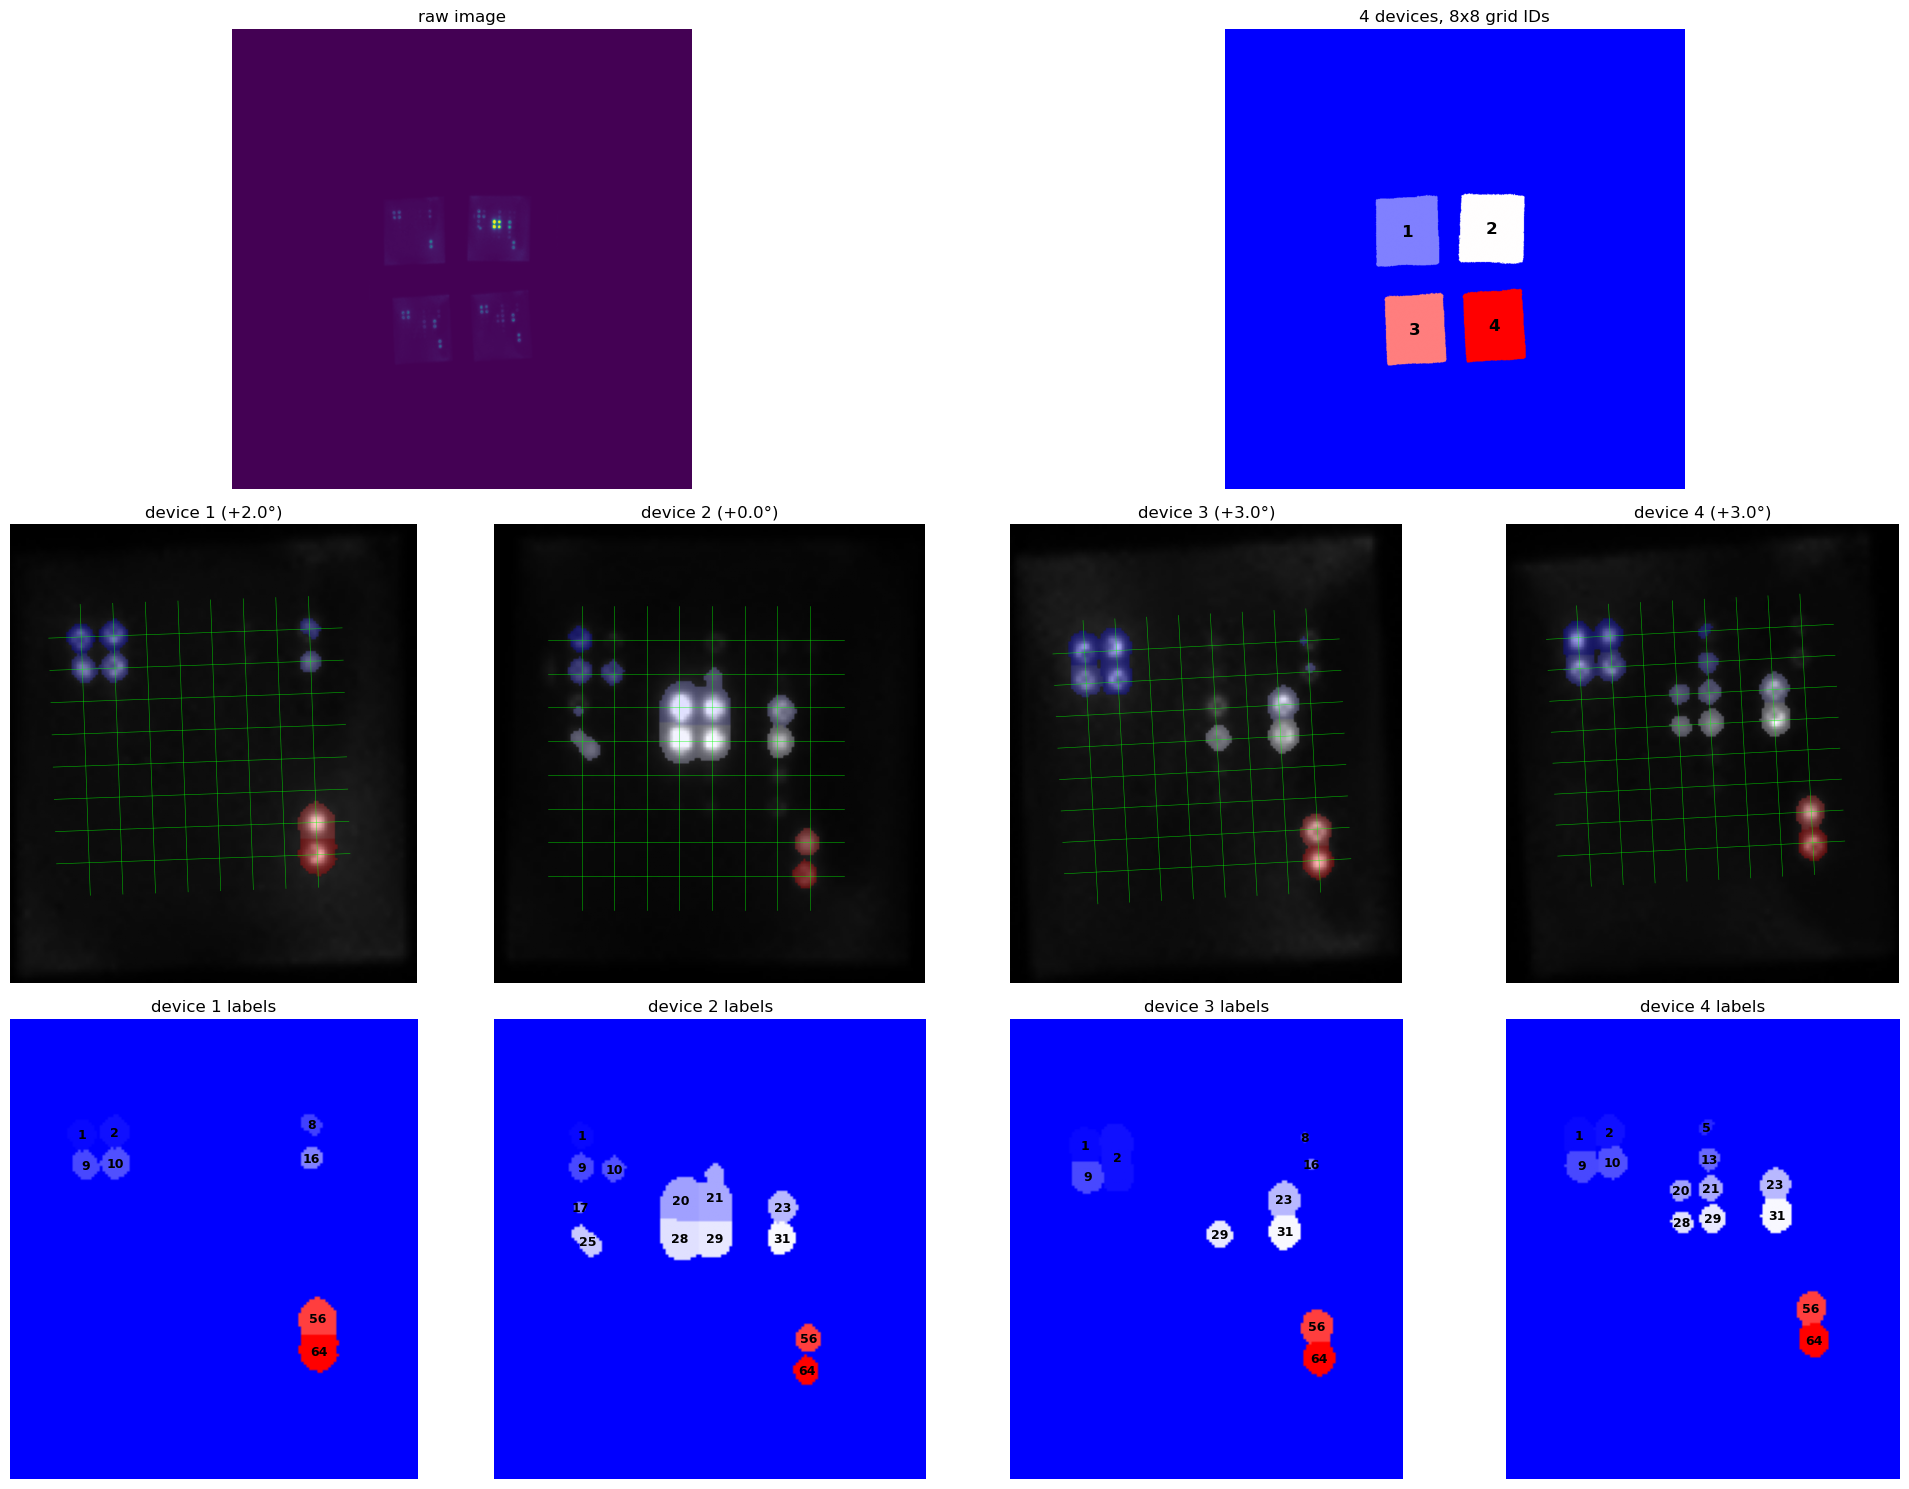

In [112]:
# folder = r"Z:\Dorota_Avalon\cytokine array\cytokine array devices\c1"
# image_name = "IM000252"

# folder = r"Z:\Dorota_Avalon\cytokine array\cytokine array devices\c2"
# image_name = "IM000225"

folder = r"Z:\Dorota_Avalon\cytokine array\Cytokine_array_FBs\Dorota\c1"
image_name = "20250122_FB_c1_11"
identify_devices_and_quantify(folder, image_name)